# Занятие 7. Сбор данных из интернета: парсинг и API



## Зачем уметь собирать данные?

### Реальность работы аналитика

Большинство интересных данных **не лежат в готовом CSV-файле**.

Представьте задачи:
- Отследить, как меняются цены на авиабилеты в зависимости от дня покупки
- Узнать, какие навыки чаще всего требуют в вакансиях Python-разработчика
- Построить карту землетрясений за последний месяц
- Сравнить курс рубля с новостным фоном

Во всех этих случаях данные **есть в интернете** — но их нужно уметь достать.




### Два способа получить данные из интернета

| Способ | Когда использовать | Пример |
|---|---|---|
| **Парсинг HTML** | Сайт отображает данные на странице, но API нет | Новостные сайты, каталоги товаров |
| **API** | Сервис специально предоставляет данные в удобном формате | Погода, финансы, госданные |

**Парсинг** — это как прочитать содержимое веб-страницы программно.  
**API** — это как позвонить на склад и попросить конкретный товар по каталогу.

API предпочтительнее там, где он есть: данные структурированы, не нужно следить за вёрсткой сайта, меньше риск блокировки.

---
## Часть 1. Как работает HTTP-запрос

Прежде чем писать код — нужно понять, что именно происходит, когда браузер открывает страницу.

### Схема взаимодействия

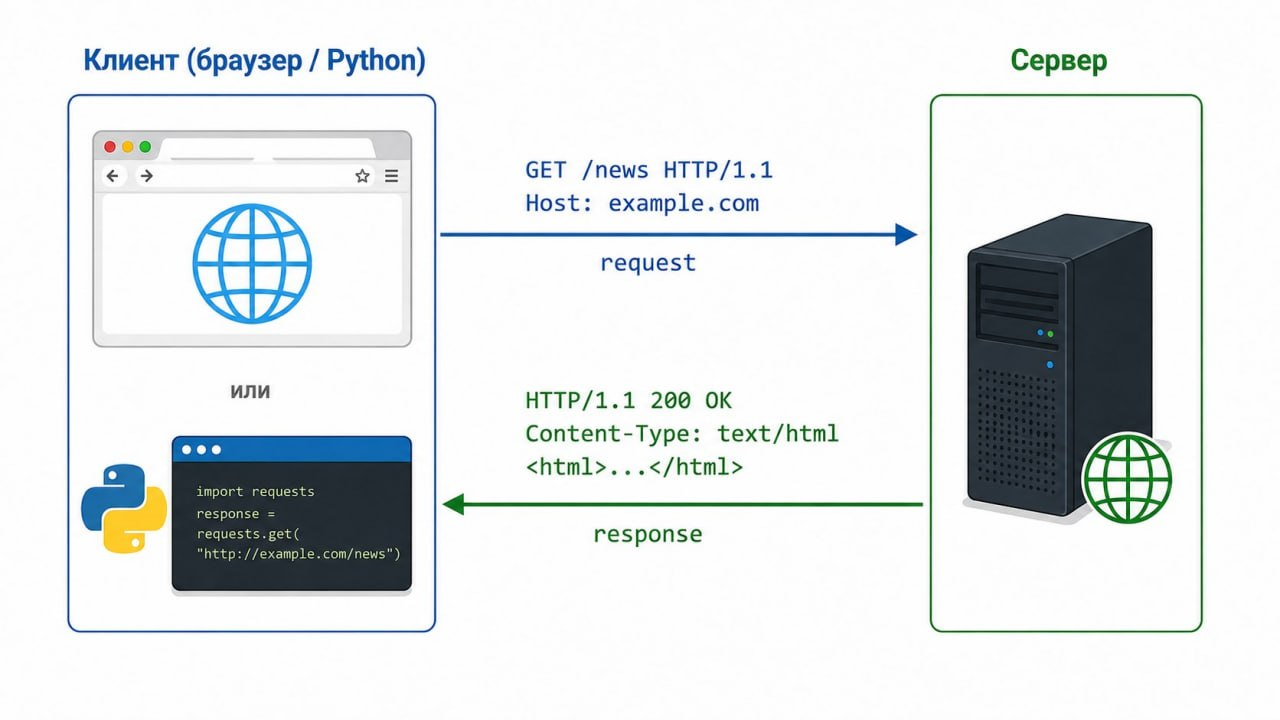

Клиент отправляет **запрос** (request), сервер возвращает **ответ** (response).

---

### Коды состояния (status codes)

Сервер всегда возвращает числовой код и по нему мы можем понять, что произошло:

| Код | Значение | Что делать |
|---|---|---|
| **200** | OK — всё хорошо | Работаем с данными |
| **301/302** | Редирект | `requests` обрабатывает автоматически |
| **403** | Forbidden — сервер нас отклонил | Добавить заголовок `User-Agent` |
| **404** | Not Found — страница не существует | Проверить URL |
| **429** | Too Many Requests — слишком часто стучимся | Добавить `time.sleep()` |
| **500** | Internal Server Error — ошибка на сервере | Повторить запрос позже |



### Как посмотреть запросы в браузере

Откройте любой сайт → **F12** → вкладка **Network** → обновите страницу.  
Вы увидите все HTTP-запросы: к HTML, CSS, картинкам, API-вызовы.

Вы можете воспользоваться этим инструментом, чтобы «подглядеть»,  какие запросы делает сайт, и повторить их в Python.



## Часть 2. Библиотека `requests`

В Python есть встроенный модуль `urllib` для HTTP-запросов, но он неудобен: много шаблонного кода, сложная обработка ошибок. Поэтому на практике все используют стороннюю библиотеку **requests**.

Её автор Кеннет Рейтц называет её **«HTTP для людей»**.

```
pip install requests
```

если выполняете в ячейке, добавьте в начале "%"


### 2.1. Первый запрос и объект `Response`

`requests.get(url)` возвращает не просто текст страницы, а объект **`Response`** —  
со всеми данными ответа: статусом, заголовками, содержимым.

> `httpbin.org` — специальный тестовый сервис для разработчиков.  
> Он «отражает» запросы обратно: что отправил — то и получил в ответе.  
> Это удобно, когда нужно просто посмотреть, как работает библиотека.


In [ ]:
import requests

response = requests.get('https://httpbin.org/get')

# Объект Response содержит всю информацию об ответе
print('Тип объекта:', type(response))
print('Статус-код: ', response.status_code)
print('URL запроса:', response.url)
print('Тип содержимого:', response.headers['Content-Type'])


### 2.2. Содержимое ответа: `.text` и `.json()`

Объект `Response` хранит тело ответа — его можно прочитать двумя способами:

| Атрибут / метод | Что возвращает | Когда использовать |
|---|---|---|
| `response.text` | строка | HTML-страницы |
| `response.json()` | словарь или список Python | JSON-ответы от API |


In [ ]:
response = requests.get('https://httpbin.org/json')

# .text — это просто длинная строка
print('--- .text ---')
print(type(response.text))
print(response.text)

print()

# .json() — сразу готовый словарь Python
print('--- .json() ---')
data = response.json()
print(type(data))
print(data)


### 2.3. Параметры запроса: `params=`

Большинство API принимают параметры в строке URL — они идут после знака `?`:

```
https://archive-api.open-meteo.com/v1/archive?latitude=55.75&longitude=37.62&start_date=2024-01-01
```

Писать такой URL вручную неудобно и ненадёжно — особенно когда параметров много.  
`requests` позволяет передавать параметры словарём через аргумент `params=`  
и **сам** собирает итоговый URL.


In [ ]:
url = 'https://archive-api.open-meteo.com/v1/archive' # возьмём данные с сайта Open-Meteo

params = {
    'latitude':   55.75,
    'longitude':  37.62,
    'start_date': '2024-01-01',
    'end_date':   '2024-01-05',
    'daily':      'temperature_2m_mean'
}

response = requests.get(url, params=params)

# Смотрим, какой URL собрал requests
print('Итоговый URL:', response.url)
print('Статус:', response.status_code)

data = response.json()
print('Даты:', data['daily']['time'])
print('Температуры:', data['daily']['temperature_2m_mean'])


### 2.4. Заголовки запроса: `headers=`

Каждый HTTP-запрос содержит **заголовки** — служебные поля с информацией о клиенте.  
Один из них — `User-Agent` — сообщает серверу, кто делает запрос.

Браузер отправляет что-то вроде:
```
User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0
```

Если сервер видит, что запрос пришёл не из браузера, он может вернуть **403 Forbidden**.  
Решение — явно указать `User-Agent` в заголовках запроса.

> **Вопрос на понимание:** сервер не может физически проверить, действительно ли запрос  
> пришёл из Chrome — мы можем написать в `User-Agent` что угодно.  
> Почему тогда многие сайты всё равно используют эту проверку?


In [ ]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/120.0.0.0 Safari/537.36'
}
# Это стандартная строка идентификации браузера Chrome на Windows.
# Исторически сложилась как набор «совместимостей» — каждый новый браузер добавлял в строку упоминание предыдущих,
# чтобы сервер его не заблокировал.

response = requests.get('https://httpbin.org/headers', headers=headers)

# Сервис httpbin отражает заголовки обратно — видим, что отправили
print(response.json())


### 2.5. Проверка ошибок: `raise_for_status()`

Даже при ошибке на сервере (404, 500) `requests` **не выбрасывает исключение** — он спокойно возвращает объект `Response` с плохим статус-кодом. И если сразу обратиться к `.json()`, получим невнятный `JSONDecodeError` вместо понятного сообщения об ошибке.

`raise_for_status()` решает это: он проверяет код и сразу выбрасывает исключение, если что-то пошло не так.


In [ ]:
# Без проверки — тихий сбой, непонятная ошибка
response = requests.get('https://httpbin.org/status/404')
print('Статус:', response.status_code)   # 404, но исключения нет

# С raise_for_status() — сразу понятно, что произошло
try:
    response = requests.get('https://httpbin.org/status/404')
    response.raise_for_status()
    data = response.json()
except requests.exceptions.HTTPError as e:
    print(f'Ошибка: {e}')


---
## Часть 3. HTML и BeautifulSoup

### Структура HTML

HTML — это дерево тегов. Каждый тег может иметь **атрибуты** и **содержимое**.

```html
<div class="article">
    <h2>Заголовок статьи</h2>
    <p class="date">28 мая 2026</p>
    <a href="/article/123">Читать далее</a>
</div>
```

Чтобы извлечь данные из HTML программно — нужно уметь находить нужные теги.  
Для этого используется библиотека **BeautifulSoup**.

`pip install bs4`

### Как найти нужный тег: DevTools

Прежде чем писать код — откройте сайт в браузере:

1. **F12** → вкладка **Elements**
2. Нажмите иконку курсора (или **Ctrl+Shift+C**)
3. Кликните на элемент, который хотите спарсить
4. Браузер подсветит соответствующий HTML-тег

Это покажет вам имя тега, класс (`class=`), идентификатор (`id=`) — всё, что нужно для поиска.  
Умение работать с DevTools — **главный навык парсера**.


In [ ]:
import requests
from bs4 import BeautifulSoup

# Загружаем учебную страницу для парсинга
url = 'https://books.toscrape.com/'
response = requests.get(url)
response.encoding = 'utf-8'

# Создаём объект BeautifulSoup — передаём HTML и парсер
soup = BeautifulSoup(response.text, 'html.parser')

print('Тип объекта:', type(soup))
print('Заголовок страницы:', soup.title.text)


### Методы поиска элементов

| Метод | Что делает | Возвращает |
|---|---|---|
| `soup.find(tag)` | Находит **первый** элемент | Один тег или `None` |
| `soup.find(tag, {'class': 'name'})` | Первый элемент с атрибутом | Один тег или `None` |
| `soup.find_all(tag)` | Находит **все** элементы | Список тегов |
| `.text` / `.get_text()` | Извлекает текст из тега | Строка |
| `.get('href')` | Извлекает значение атрибута | Строка или `None` |


In [ ]:
# Найти один элемент
first_book = soup.find('article', {'class': 'product_pod'})
print(first_book)


In [ ]:
# Найти все элементы и пройтись по ним
books = soup.find_all('article', {'class': 'product_pod'})
print(f'Книг на странице: {len(books)}')

# Извлекаем данные из каждого элемента
for book in books[:3]:
    title  = book.find('h3').find('a').get('title')
    price  = book.find('p', {'class': 'price_color'}).text.strip()
    rating = book.find('p', {'class': 'star-rating'}).get('class')[1]
    print(f'{title} | {price} | Рейтинг: {rating}')


In [ ]:
import pandas as pd

# Собираем все книги в датафрейм — стандартный паттерн парсинга
result = []
for book in books:
    result.append({
        'title':  book.find('h3').find('a').get('title'),
        'price':  book.find('p', {'class': 'price_color'}).text.strip(),
        'rating': book.find('p', {'class': 'star-rating'}).get('class')[1],
        'url':    'https://books.toscrape.com/' + book.find('a').get('href')
    })

df = pd.DataFrame(result)
df.head()


---
### 🔹 Мини-задача (4 мин)

На той же странице `books.toscrape.com` найдите:

1. Сколько всего книг в каталоге?  
2. Сколько книг на главной странице имеют рейтинг `'One'`?

In [ ]:
# Ваш код здесь


---
## Часть 4. Парсинг таблиц с `pandas`

Если на странице есть HTML-тег `<table>` — pandas умеет извлечь её буквально в одну строку.

### Зависимости

`pd.read_html` не умеет читать HTML самостоятельно — она делегирует это сторонним парсерам.
Если при запросе к сайту вы видите `ModuleNotFoundError` — просто установите недостающий пакет.

Рекомендуется установить оба заранее:

`pip install lxml`

`pip install html5lib`

Вот, например, обычная страница Википедии с замечательной таблицей:

[Список государств и зависимых территорий по населению](https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D0%B3%D0%BE%D1%81%D1%83%D0%B4%D0%B0%D1%80%D1%81%D1%82%D0%B2_%D0%B8_%D0%B7%D0%B0%D0%B2%D0%B8%D1%81%D0%B8%D0%BC%D1%8B%D1%85_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9_%D0%BF%D0%BE_%D0%BD%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8E)

попробуем скачать её:

In [ ]:
import pandas as pd

# Пример: https://testautomationpractice.blogspot.com/ - учебный сайт с простой структурой для парсинга
tables = pd.read_html('https://testautomationpractice.blogspot.com/')

print(f'Найдено таблиц на странице: {len(tables)}')
print(f'Тип результата: {type(tables)}')

# Смотрим первую таблицу
df = tables[0]
print(f'Размер: {df.shape}')
df.head()


**Почему `read_html` возвращает список, а не датафрейм?**  
На одной странице может быть несколько таблиц — навигация, основные данные, сноски.  
`read_html` находит все теги `<table>` и возвращает список, чтобы вы сами выбрали нужную.

**Когда это работает?**  
Только если данные находятся в настоящем HTML-теге `<table>`.  
Если таблица нарисована через `<div>` и CSS — нужен BeautifulSoup.


---
## Часть 5. JSON и REST API

### Что такое JSON

JSON (JavaScript Object Notation) — универсальный формат обмена данными в интернете.  
Выглядит почти как словари и списки Python:

```json
{
  "city": "Moscow",
  "temperature": -3.5,
  "conditions": ["cloudy", "windy"],
  "forecast": null
}
```

| JSON | Python |
|---|---|
| `{ }` | `dict` |
| `[ ]` | `list` |
| `"строка"` | `str` |
| `123`, `5.2` | `int`, `float` |
| `true` / `false` | `True` / `False` |
| `null` | `None` |



### Что такое REST API

**REST API** — интерфейс, через который сервер отдаёт данные по запросу.

Запрос = URL + параметры → Ответ = JSON

Пример: API Open-Meteo отдаёт исторические данные о погоде бесплатно, без регистрации (и смс).  Мы с ним уже немного познакомились.
Документация: https://open-meteo.com/en/docs/historical-weather-api

```
GET https://archive-api.open-meteo.com/v1/archive
    ?latitude=55.75
    &longitude=37.62
    &start_date=2024-01-01
    &end_date=2024-01-07
    &daily=temperature_2m_mean
```


In [ ]:
import requests

# Исторические данные о температуре в Москве за первую неделю 2024 года
url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude':    55.75,
    'longitude':   37.62,
    'start_date':  '2024-01-01',
    'end_date':    '2024-01-07',
    'daily':       'temperature_2m_mean'
}

response = requests.get(url, params=params)
print('Статус:', response.status_code)

data = response.json()
print('Ключи верхнего уровня:', list(data.keys()))


### Разбор структуры ответа

Реальные API почти всегда возвращают **вложенные** структуры.  
Ключевой навык — уметь «распаковать» их в плоский датафрейм.

Посмотрим, что внутри:


In [ ]:
# Изучаем структуру ответа
print('Город:', data.get('timezone'))
print('Единицы:', data.get('daily_units'))
print()
print('Ключи блока daily:', list(data['daily'].keys()))
print()
print('Даты:', data['daily']['time'])
print('Температуры:', data['daily']['temperature_2m_mean'])


### Сборка датафрейма из JSON

Когда данные в JSON уже представлены как словарь списков, `pd.DataFrame` справится напрямую.  
Когда данные вложены глубже — нужен цикл.


In [ ]:
import pandas as pd

# Вариант 1: словарь списков → датафрейм напрямую
df = pd.DataFrame(data['daily'])
df['time'] = pd.to_datetime(df['time'])
df.columns = ['date', 'temp_mean']
df


In [ ]:
# Запросим данные за целый год и построим помесячную динамику
params_year = {
    'latitude':   55.75,
    'longitude':  37.62,
    'start_date': '2024-01-01',
    'end_date':   '2024-12-31',
    'daily':      'temperature_2m_mean'
}

response_year = requests.get(url, params=params_year)
data_year = response_year.json()

df_year = pd.DataFrame(data_year['daily'])
df_year['time'] = pd.to_datetime(df_year['time'])
df_year.columns = ['date', 'temp_mean']

# Средняя температура по месяцам
monthly = df_year.groupby(df_year['date'].dt.month)['temp_mean'].mean().round(1)
print('Средняя температура по месяцам в Москве, 2024:')
monthly


---
### 🔹 Мини-задача (4 мин)

Используйте тот же API Open-Meteo, но для **вашего родного города** (или любого на выбор).

1. Найдите координаты города (широта и долгота) — например, через Google Maps
2. Запросите среднюю температуру за январь 2024 года
3. Вычислите среднюю, минимальную и максимальную температуру за этот месяц


In [ ]:
# Ваш код здесь


---
## Часть 6. Практические паттерны и подводные камни

Это то, что может быть не написано в документации, но с чем вы точно столкнётесь.

### 1. Сервер отклоняет запрос (403 Forbidden)

Некоторые сайты блокируют запросы, если понимают, что их делает не браузер.  
Решение — добавить заголовок `User-Agent`, представившись браузером.

Простой пример - страница с Википедии:


In [ ]:
import pandas as pd

# Пример: таблица населения стран мира с Wikipedia
tables = pd.read_html('https://ru.wikipedia.org/wiki/Список_государств_и_зависимых_территорий_по_населению')

print(f'Найдено таблиц на странице: {len(tables)}')
print(f'Тип результата: {type(tables)}')

# Смотрим первую таблицу
df = tables[0]
print(f'Размер: {df.shape}')
df.head()


Да, мы получили `HTTP Error 403: Forbidden`

**Почему?**

Дело в том, что `pd.read_html` использует внутри `urllib` без какого-либо `User-Agent`, и большинство современных сайтов блокируют такие запросы. Это общая тенденция последних лет.

**Решение**: скачать страницу через `requests` с заголовком, а потом передать HTML-текст в `pd.read_html`:



In [ ]:
import requests
import pandas as pd

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/124.0.0.0'}
response = requests.get(
    'https://ru.wikipedia.org/wiki/Список_государств_и_зависимых_территорий_по_населению',
    headers=headers
)

tables = pd.read_html(response.text)
print(f'Найдено таблиц: {len(tables)}')
df = tables[0]
df.head()

### 2. Слишком много запросов (429 Too Many Requests)

Допустим, вам с сайта нужно спарсить 150 страниц.

Если отправлять запросы в цикле без паузы — сервер может временно заблокировать ваш IP.  

Решение — добавить задержку между запросами с помощью `time.sleep()`:


In [ ]:
import requests
import time

url = 'https://www.speedtest.net/api/js/speedtest'

for i in range(62):
    response = requests.get(url)
    print(f"Попытка {i+1}: {response.status_code}")
    if response.status_code == 429:
        print("❌ Получена ошибка 429 Too Many Requests!")
        break
    # time.sleep(1)

### 3. Проверка статуса и обработка ошибок

Всегда проверяйте успешность запроса **перед** тем, как работать с данными.  
Иначе при ошибке сервера вы получите невнятный `KeyError` вместо понятного сообщения:


In [ ]:
# Способ 1 — ручная проверка статуса
response = requests.get('https://httpbin.org/status/404')

if response.status_code == 200:
    data = response.json()
    print('Данные получены')
else:
    print(f'Ошибка: {response.status_code}')


In [ ]:
# Способ 2 — raise_for_status() автоматически выбрасывает исключение при 4xx/5xx
try:
    response = requests.get('https://httpbin.org/status/500')
    response.raise_for_status()      # если статус не 2xx — исключение
    data = response.json()
    print('OK')
except requests.exceptions.HTTPError as e:
    print(f'HTTP-ошибка: {e}')
except requests.exceptions.ConnectionError:
    print('Нет соединения с сервером')


### 4. Кодировка страницы

Иногда кириллица на странице отображается как кракозябры.  
Причина — `requests` иногда неверно определяет кодировку ответа.

Проверим на такой странице: 'https://bugtraq.ru/'  


In [ ]:
url = 'https://bugtraq.ru/'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
divs = soup.find_all('div', {'class': 'l'})

print(f'Кодировка, которую определил requests: {response.encoding}')
print('Текст (с "крякозябрами"):')
print(divs[1].get_text(strip=True))

# print('РЕШЕНИЕ: принудительно указываем правильную кодировку')
# response.encoding = 'Windows-1251'
# soup = BeautifulSoup(response.text, 'html.parser') # важно! нужно пересоздать BS!!!
# divs = soup.find_all('div', {'class': 'l'})
# print(divs[1].get_text(strip=True))

---
## Итоги занятия

| Тема | Ключевые инструменты |
|---|---|
| HTTP-запрос | `requests.get(url, params=, headers=)` |
| Статус ответа | `response.status_code`, `response.raise_for_status()` |
| Содержимое ответа | `response.text`, `response.json()`, `response.encoding` |
| Парсинг HTML | `BeautifulSoup(html, 'html.parser')` |
| Поиск элементов | `.find(tag, {'class': ...})`, `.find_all(...)` |
| Извлечение данных | `.text`, `.strip()`, `.get('атрибут')` |
| Парсинг таблиц | `pd.read_html(url)` → список датафреймов |
| JSON | `response.json()` → словарь / список Python |
| Сборка датафрейма | `pd.DataFrame(data['ключ'])` или цикл → список словарей |
| Защита от блокировок | `headers={'User-Agent': ...}`, `time.sleep()` |
| Обработка ошибок | `status_code`, `raise_for_status()`, `try/except` |

---

### Когда что использовать

| Ситуация | Инструмент |
|---|---|
| Данные в HTML-таблице `<table>` | `pd.read_html()` |
| Данные разбросаны по HTML-тегам | `requests` + `BeautifulSoup` |
| Сервис предоставляет API | `requests` + `.json()` |
| Ответ API — вложенный JSON | цикл + извлечение полей + `pd.DataFrame` |

---

### Полезные ссылки

- [Документация requests](https://requests.readthedocs.io/en/latest/)
- [Документация BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)
- [HTTP статус-коды — справочник MDN](https://developer.mozilla.org/ru/docs/Web/HTTP/Status)
- [JSONLint — проверить и красиво отобразить JSON](https://jsonlint.com/)
- [books.toscrape.com — учебный сайт для парсинга](https://books.toscrape.com/)
- [Open-Meteo — бесплатный погодный API](https://open-meteo.com/)


